# 11 — Measured vs Calculated Efficiency

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Compare the V1 board's measured efficiency (fan-PWM ramps at 5, 9, 15 and 20 V input,
2026-09-15) with the loss model of notebooks 03 and 04, extended from their single 5 V / 3 A design point to
every measured operating point (buck and boost, ~1–36 W), and size the loss the model does not account for.

**Design basis (V1):** as built. BSC0902NSI in all four positions with BIAS tied to VOUT (7.35 V gate
drive), Würth 7443634700 47 µH, f_sw = 100 kHz, 10 mΩ current-sense resistor (notebook 07).

**Key result — decision:** the notebook 03/04 loss model is optimistic at every measured point. Above
~5 W it predicts 0.25–1.0 points more efficiency than measured. At ~3 A inductor current it accounts for
68 % of the measured loss in boost (5 and 9 V), leaving 0.13–0.14 W unexplained, but only 59 % at 15 V
(0.21 W unexplained) and 55 % at 20 V (0.30 W) in buck. Near the Objective 1 corner (4.66 V, 2.85 A in)
the board measures 96.8 % against 97.8 % calculated. No V1 part choice changes from this comparison.
The unexplained 0.14 W there is larger than the 14–84 mW part differences notebooks 03 and 04 ranked
on, so those rankings compare modeled terms only, not what the board loses.

**See also:** 03 (inductor loss), 04 (FET loss model), 05 (capacitors), 07 (sense resistor), 08 (input
filter), `measurements/efficiency/README.md` (test setup, calibration, caveats),
`measurements/test setup/efficiency_esp32/` (logger and analysis scripts).

## Measured data

The four clean 10-fan runs, one per USB PD voltage, logged by the board's INA226s
(`measurements/efficiency/README.md` has the setup, the files that were excluded, and the calibration
caveats). Every number below comes from those captures through the same code the plotting scripts use
(`plot_efficiency.load`):

- **Input power:** input INA226, DMM-calibrated (`133151_shunt_cal_in`; DMM in the supply harness).
- **Output power:** fan-rail voltage × sum of the ten per-fan currents (DMM-calibrated, `154613`), plus
  the 5 V buck input power from its own INA226. This is the converter's whole 12 V output.
- **Binning:** up and down ramps pooled, then averaged in output-power bins; bins with fewer than
  3 readings are dropped.
- **Precision:** up/down agreement and calibration scatter are ~0.1–0.5 % at mid and high power. Below
  ~2 W the fan-rail offset limits efficiency to about ±1.3 points.

In [1]:
import sys; sys.path.insert(0, '..')                                   # repo root: constants.py
sys.path.insert(0, '../measurements/test setup/efficiency_esp32')      # efficiency analysis tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constants as cfg
from constants import IC_LM5176 as IC
from calibrate_shunts import load_calibration
from plot_efficiency import load

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

MEAS = '../measurements/efficiency/'
RUNS = {5: '2026-09-15_151555_fans_5V.csv', 9: '2026-09-15_151955_fans_9V.csv',
        15: '2026-09-15_141025_fans_15V.csv', 20: '2026-09-15_141459_fans_20V.csv'}
CAL = [MEAS + '2026-09-15_133151_shunt_cal_in.csv', MEAS + '2026-09-15_154613_shunt_cal_fan12.csv::b5in']
P_BINS = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.5, 8.0, 10.0, 12.5, 15.0, 17.5, 20.0,
          22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5]

cal = load_calibration(CAL)
for ch, (gain, offset) in cal.items():
    print(f"calibration {ch:6s}: I = {gain:.4f} x nominal {offset*1e3:+.1f} mA")

bins = []
for vin_nom, fname in RUNS.items():
    df, active, fans = load(MEAS + fname, cal)
    g = active.groupby(pd.cut(active['P_out'], P_BINS), observed=True)
    b = pd.DataFrame({'P_out_W': g['P_out'].mean(), 'P_in_W': g['P_in'].mean(), 'Vin_V': g['in_V'].mean(),
                      'Vout_V': g['fan12_V'].mean(), 'rows': g.size()})
    b = b[b['rows'] >= 3].reset_index(drop=True)
    b.insert(0, 'Vin_nom', vin_nom)
    bins.append(b)
meas = pd.concat(bins, ignore_index=True)
meas['eta_meas'] = meas['P_out_W'] / meas['P_in_W']
meas['loss_meas_W'] = meas['P_in_W'] - meas['P_out_W']
print(f"\n{len(meas)} measured bins")
print(meas.round(4).to_string(index=False))

calibration fan12 : I = 0.9141 x nominal -0.7 mA
calibration fansum: I = 0.9852 x nominal +2.4 mA
calibration in    : I = 0.8996 x nominal +4.3 mA

63 measured bins
 Vin_nom  P_out_W  P_in_W   Vin_V  Vout_V  rows  eta_meas  loss_meas_W
       5   1.0939  1.2142  5.0298 12.0826    44    0.9009       0.1203
       5   1.8361  1.9633  5.0091 12.0829    51    0.9352       0.1272
       5   2.5280  2.6617  4.9896 12.0831    95    0.9497       0.1338
       5   3.4919  3.6359  4.9621 12.0838    70    0.9604       0.1439
       5   4.4876  4.6416  4.9332 12.0841    54    0.9668       0.1540
       5   5.7309  5.9045  4.8964 12.0850    68    0.9706       0.1736
       5   7.2257  7.4346  4.8510 12.0845    51    0.9719       0.2089
       5   8.9794  9.2371  4.7960 12.0843    60    0.9721       0.2576
       5  11.1441 11.4703  4.7261 12.0837    56    0.9716       0.3262
       5  13.0026 13.4304  4.6620 12.0851    16    0.9681       0.4278
       9   1.0959  1.1966  9.1357 12.0786    36    0.9

## Loss model

The terms and formulas of notebooks 03 (inductor) and 04 (FETs), for the V1 parts, evaluated at every
measured operating point instead of only at 5 V / 3 A. Notebook 04 models boost mode only; the buck-mode
versions below apply the same expressions to the buck switches. All values are 25 °C datasheet typicals.

| Term | Expression | Source |
|---|---|---|
| Inductor DC | I_L,rms² · 12.2 mΩ (`Rs_spice_Ohm`; REDEXPERT's P_dc / I² reproduces it) | notebook 03 |
| Inductor AC | V_L,rms² / R_p (SPICE-model parallel resistance) | notebook 03 Rp model |
| FET conduction | 2 · I_L,rms² · R_DS(on)(7.35 V) | notebook 04 |
| FET switching (V–I) | ½ · V_sw · f · (max(I_valley, 0) · t_on + I_peak · t_off). Boost: QL2 on the low-side driver, V_sw = V_out. Buck: QH1 on the high-side driver (1.8 Ω / 1.1 Ω), V_sw = V_in | notebook 04; buck version new |
| FET C_oss | Q_oss(V_sw) · V_sw · f; when I_valley < 0, reduced by ½ · L · I_valley² (partial zero-voltage turn-on) | notebook 04; the valley rule is new |
| Dead-time diode | t_DT · f · V_SD · (\|I_peak\| + \|I_valley\|) | notebook 04 (equal to 2 · t_DT · f · V_SD · I_L when I_valley > 0) |
| Reverse recovery | Q_rr · min(1, I_valley / I_F,test) · V_sw · f, for I_valley > 0 | notebook 04 |
| Gate drive | 2 · Q_g(7.35 V) · f · V_out (BIAS tied to VOUT) | notebook 04 case A; two switching FETs in both modes (notebook 04 cell 13) |
| Current-sense resistor | I_L,rms² · 10 mΩ · D_low, D_low = D (boost) or 1 − D (buck) | 10 mΩ from notebook 07; in the low-side switch source path (designer, 2026-09-17), so it conducts only while that switch is on; term new |
| Controller | V_in · 2 mA (I_Q typical) | notebook 03 |

**Assumptions:**
- **Forced continuous conduction at light load**, as in notebook 03. The LM5176 MODE setting on V1 is
  not recorded in the repository.
- **Ideal duty cycle**, and pure buck (V_in > V_out) or pure boost. The controller's buck-boost
  transition region is not modeled, and whether 15 V (D = 0.80) runs in it is not checked.
- **Boost input current is iterated:** I_L = P_in / V_in includes the modeled loss.

**Not modeled** (all of these are inside the measured loss):
- input PMOS rework and input filter (notebook 08), and the LM5176 input average-current sense
  resistor if fitted (value not recorded);
- the 1 mΩ INA226 shunts and PCB copper between the input and output measurement points;
- output-capacitor ESR, UVLO latch and divider bias current;
- R_DS(on) temperature rise, ringing and common-source inductance, bootstrap-diode drop.

In [2]:
fets = pd.read_csv('../data/mosfets.csv').set_index('Part_Number')
inds = pd.read_csv('../data/inductors.csv', dtype={'Part_Number': str}).set_index('Part_Number')
fet, ind = fets.loc[cfg.ACTIVE_FET_ID], inds.loc[cfg.ACTIVE_IND_ID]

F_SW = cfg.DESIGN.F_SW_HZ
V_DRV = IC.V_VCC_NOM            # BIAS tied to VOUT: VCC regulates at every input voltage (notebook 04, case A)
L = ind['Inductance_uH'] * 1e-6
R_DC = ind['Rs_spice_Ohm']      # typical-equivalent DCR (notebook 03 check against REDEXPERT P_dc)
R_P = ind['Rp_Ohm']
R_SENSE = 0.010                 # LM5176 current-sense resistor (notebook 07)

# R_DS(on) and Q_g at V_DRV, as notebook 04: R = R0 + K/(V - Vth) through the 4.5 V and 10 V table values; Q_g linear
vth = fet['VGS_th_Typ(V)'] if pd.notna(fet['VGS_th_Typ(V)']) else 0.5 * (fet['VGS_th_Min(V)'] + fet['VGS_th_Max(V)'])
(v1, r1), (v2, r2) = (4.5, fet['RDSon_4.5V_Typ(mOhm)']), (10.0, fet['RDSon_10V_Typ(mOhm)'])
k = (r1 - r2) / (1 / (v1 - vth) - 1 / (v2 - vth))
RDS_ON = (r2 - k / (v2 - vth) + k / (V_DRV - vth)) * 1e-3
Q_G = (fet['Qg_4.5V_Typ(nC)'] + (fet['Qg_10V_Typ(nC)'] - fet['Qg_4.5V_Typ(nC)']) * (V_DRV - 4.5) / 5.5) * 1e-9
Q_GD, R_G, V_PL = fet['Qgd_Typ(nC)'] * 1e-9, fet['RG_Internal_Typ(Ohm)'], fet['Vplateau_Typ(V)']


def q_oss(v):
    # Q_oss at V_DS = v: table value at its test voltage shifted by C_oss(test) (notebook 04's correction)
    return (fet['Qoss_Typ(nC)'] + (v - fet['Cap_Test_VDS(V)']) * fet['Coss_Typ(pF)'] * 1e-3) * 1e-9


def model_losses(v_in, v_out, p_out):
    """Modeled loss terms (W) at an operating point, plus the operating-point values used."""
    buck = v_in > v_out
    p_in = p_out
    for _ in range(50):
        if buck:   # QH2 held on; QH1 hard-switched by the high-side driver, QL1 synchronous
            d = v_out / v_in
            i_l = p_out / v_out
            ripple = (v_in - v_out) * d / (L * F_SW)
            v_sw, r_on, r_off, d_low = v_in, IC.R_HDRV_PULLUP, IC.R_HDRV_PULLDOWN, 1 - d
            v_l_rms2 = (v_in - v_out) ** 2 * d + v_out ** 2 * (1 - d)
        else:      # QH1 held on; QL2 hard-switched by the low-side driver, QH2 synchronous
            d = 1 - v_in / v_out
            i_l = p_in / v_in
            ripple = v_in * d / (L * F_SW)
            v_sw, r_on, r_off, d_low = v_out, IC.R_LDRV_PULLUP, IC.R_LDRV_PULLDOWN, d
            v_l_rms2 = v_in ** 2 * d + (v_in - v_out) ** 2 * (1 - d)
        i_rms2 = i_l ** 2 + ripple ** 2 / 12
        i_pk, i_val = i_l + ripple / 2, i_l - ripple / 2
        t_on = Q_GD * (r_on + R_G) / (V_DRV - V_PL)
        t_off = Q_GD * (r_off + R_G) / V_PL
        e_oss = q_oss(v_sw) * v_sw
        if i_val < 0:
            e_oss = max(0.0, e_oss - 0.5 * L * i_val ** 2)
        terms = {
            'Inductor DC': i_rms2 * R_DC,
            'Inductor AC': v_l_rms2 / R_P,
            'FET conduction': 2 * i_rms2 * RDS_ON,
            'FET switching (V-I)': 0.5 * v_sw * F_SW * (max(i_val, 0.0) * t_on + i_pk * t_off),
            'FET Coss': e_oss * F_SW,
            'FET dead-time diode': IC.T_DEADTIME * F_SW * fet['VSD_Typ(V)'] * (abs(i_pk) + abs(i_val)),
            'FET reverse recovery': (fet['Qrr_Typ(nC)'] * 1e-9 * min(1.0, i_val / fet['Qrr_Test_IF(A)'])
                                     * v_sw * F_SW) if i_val > 0 else 0.0,
            'FET gate drive': 2 * Q_G * F_SW * v_out,
            'Current sense': i_rms2 * R_SENSE * d_low,
            'Controller IQ': v_in * IC.I_Q_OPERATING_NOM,
        }
        p_new = p_out + sum(terms.values())
        if abs(p_new - p_in) < 1e-9:
            break
        p_in = p_new
    return terms, dict(mode='buck' if buck else 'boost', D=d, I_L=i_l, ripple=ripple, I_valley=i_val)


# --- Check: the notebooks' own design point, 5 V / 3 A input, 12 V output ---
p_lo, p_hi = 10.0, 15.0
for _ in range(60):                     # output power that makes P_in = 15 W
    p_mid = 0.5 * (p_lo + p_hi)
    t, op = model_losses(5.0, 12.0, p_mid)
    p_lo, p_hi = (p_mid, p_hi) if p_mid + sum(t.values()) < 15.0 else (p_lo, p_mid)
redex = pd.read_csv('../data/inductor_losses_measured.csv', dtype={'Part_Number': str})
redex = redex[(redex['Part_Number'] == cfg.ACTIVE_IND_ID) & (redex['Freq_kHz'] == F_SW / 1e3)].iloc[0]
fet_total = sum(v for name, v in t.items() if name.startswith('FET'))
print(f"R_DS(on)(7.35 V) = {RDS_ON*1e3:.3f} mOhm, Q_g(7.35 V) = {Q_G*1e9:.2f} nC, I_L = {op['I_L']:.3f} A")
print(f"FET terms       {fet_total*1e3:6.1f} mW   (notebook 04, BSC0902NSI case A: 135.6 mW)")
print(f"Inductor DC+AC  {(t['Inductor DC'] + t['Inductor AC'])*1e3:6.1f} mW   "
      f"(REDEXPERT at this point: {redex['P_dc_mW']:.0f} + {redex['P_ac_mW']:.0f} = {redex['P_total_mW']:.0f} mW)")
print(f"Total modeled   {sum(t.values())*1e3:6.1f} mW  -> efficiency {p_mid/15:.2%} at 15 W input\n")
print(pd.Series({name: v * 1e3 for name, v in t.items()}, name='mW').round(1).to_string())

R_DS(on)(7.35 V) = 2.470 mOhm, Q_g(7.35 V) = 18.31 nC, I_L = 3.000 A
FET terms        135.6 mW   (notebook 04, BSC0902NSI case A: 135.6 mW)
Inductor DC+AC   113.3 mW   (REDEXPERT at this point: 110 + 12 = 122 mW)
Total modeled    311.5 mW  -> efficiency 97.92% at 15 W input

Inductor DC             110.2
Inductor AC               3.1
FET conduction           44.6
FET switching (V-I)      10.3
FET Coss                 18.1
FET dead-time diode      14.6
FET reverse recovery      4.0
FET gate drive           44.0
Current sense            52.7
Controller IQ            10.0


## Model at the measured operating points

Each measured bin's input voltage, output voltage and output power go into the model; the model returns
its own input power. `gap_W` is measured loss minus modeled loss: everything the model does not account
for, plus measurement error.

In [3]:
GROUPS = {'Inductor': ['Inductor DC', 'Inductor AC'],
          'FET conduction': ['FET conduction'],
          'FET switching, C_oss, diodes': ['FET switching (V-I)', 'FET Coss', 'FET dead-time diode', 'FET reverse recovery'],
          'Gate drive + controller': ['FET gate drive', 'Controller IQ'],
          'Current sense': ['Current sense']}

rows = []
for r in meas.itertuples():
    t, op = model_losses(r.Vin_V, r.Vout_V, r.P_out_W)
    rows.append({**{grp: sum(t[name] for name in names) for grp, names in GROUPS.items()}, **op})
cmp = pd.concat([meas, pd.DataFrame(rows)], axis=1)
cmp['loss_model_W'] = cmp[list(GROUPS)].sum(axis=1)
cmp['eta_model'] = cmp['P_out_W'] / (cmp['P_out_W'] + cmp['loss_model_W'])
cmp['gap_W'] = cmp['loss_meas_W'] - cmp['loss_model_W']
cmp['eta_diff_pts'] = 100 * (cmp['eta_meas'] - cmp['eta_model'])
print(cmp[['Vin_nom', 'mode', 'Vin_V', 'P_out_W', 'I_L', 'I_valley', 'eta_meas', 'eta_model', 'eta_diff_pts',
           'loss_meas_W', 'loss_model_W', 'gap_W']].round(3).to_string(index=False))

 Vin_nom  mode  Vin_V  P_out_W   I_L  I_valley  eta_meas  eta_model  eta_diff_pts  loss_meas_W  loss_model_W  gap_W
       5 boost  5.030    1.094 0.230    -0.082     0.901      0.944        -4.334        0.120         0.065  0.056
       5 boost  5.009    1.836 0.383     0.071     0.935      0.957        -2.135        0.127         0.083  0.044
       5 boost  4.990    2.528 0.524     0.213     0.950      0.967        -1.676        0.134         0.088  0.046
       5 boost  4.962    3.492 0.723     0.412     0.960      0.973        -1.305        0.144         0.095  0.049
       5 boost  4.933    4.488 0.931     0.620     0.967      0.977        -1.030        0.154         0.105  0.049
       5 boost  4.896    5.731 1.195     0.885     0.971      0.979        -0.879        0.174         0.121  0.053
       5 boost  4.851    7.226 1.519     1.210     0.972      0.980        -0.855        0.209         0.144  0.065
       5 boost  4.796    8.979 1.910     1.602     0.972      0.980     

## Chart: measured vs calculated

Top row efficiency, bottom row loss, one column per input voltage. The shaded band in the bottom row is
the loss the model does not account for. The step in the 20 V model curve near 5 W is the C_oss term
turning on as the inductor valley current rises through zero (below that, the negative valley current
gives zero-voltage turn-on in the model). Saved to `figures/11_efficiency_measured_vs_calculated.png`.

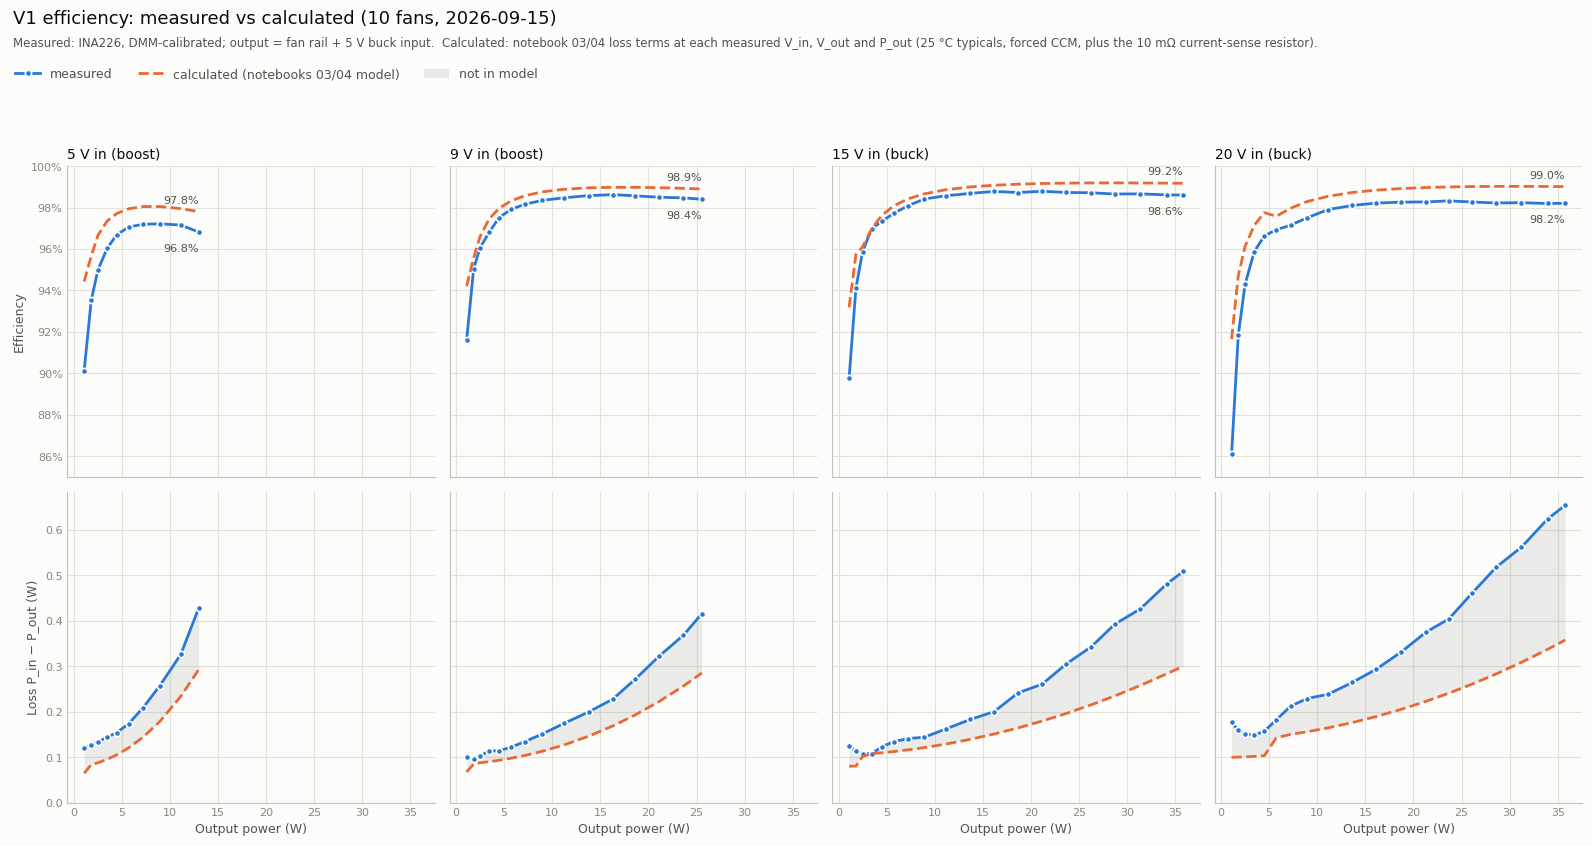

In [4]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
MEASURED, MODEL = '#2a78d6', '#eb6834'


def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=8, length=0)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_color(AXIS)


fig, axes = plt.subplots(2, 4, figsize=(16, 8.5), sharex=True, sharey='row', facecolor=SURFACE)
for col, vin in enumerate(RUNS):
    c = cmp[cmp['Vin_nom'] == vin]
    mode = c['mode'].iloc[0]
    ax = axes[0, col]
    style(ax)
    ax.plot(c['P_out_W'], c['eta_meas'], color=MEASURED, linewidth=2, marker='o', markersize=4.5,
            markeredgecolor=SURFACE, markeredgewidth=1.2, label='measured')
    ax.plot(c['P_out_W'], c['eta_model'], color=MODEL, linewidth=2, linestyle='--', label='calculated (notebooks 03/04 model)')
    ax.set_title(f"{vin} V in ({mode})", loc='left', fontsize=10, color=INK)
    top = c.iloc[-1]
    ax.annotate(f"{top['eta_meas']:.1%}", (top['P_out_W'], top['eta_meas']), xytext=(0, -14),
                textcoords='offset points', ha='right', fontsize=8, color=INK_2)
    ax.annotate(f"{top['eta_model']:.1%}", (top['P_out_W'], top['eta_model']), xytext=(0, 6),
                textcoords='offset points', ha='right', fontsize=8, color=INK_2)
    ax = axes[1, col]
    style(ax)
    ax.fill_between(c['P_out_W'], c['loss_model_W'], c['loss_meas_W'], color=MUTED, alpha=0.15, linewidth=0,
                    label='not in model')
    ax.plot(c['P_out_W'], c['loss_meas_W'], color=MEASURED, linewidth=2, marker='o', markersize=4.5,
            markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.plot(c['P_out_W'], c['loss_model_W'], color=MODEL, linewidth=2, linestyle='--')
    ax.set_xlabel('Output power (W)', fontsize=9, color=INK_2)
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
axes[0, 0].set_ylabel('Efficiency', fontsize=9, color=INK_2)
axes[1, 0].set_ylabel('Loss P_in − P_out (W)', fontsize=9, color=INK_2)
axes[1, 0].set_ylim(0, None)
h1, l1 = axes[0, 0].get_legend_handles_labels()
h2, l2 = axes[1, 0].get_legend_handles_labels()
fig.suptitle('V1 efficiency: measured vs calculated (10 fans, 2026-09-15)', x=0.01, y=0.99, ha='left',
             fontsize=13, color=INK)
fig.text(0.01, 0.947, 'Measured: INA226, DMM-calibrated; output = fan rail + 5 V buck input.  '
         'Calculated: notebook 03/04 loss terms at each measured V_in, V_out and P_out '
         '(25 °C typicals, forced CCM, plus the 10 mΩ current-sense resistor).', fontsize=8.5, color=INK_2)
fig.legend(h1 + h2, l1 + l2, loc='upper left', ncol=3, frameon=False, fontsize=9, labelcolor=INK_2,
           bbox_to_anchor=(0.004, 0.935))
fig.tight_layout(rect=[0, 0, 1, 0.885])
fig.savefig('../figures/11_efficiency_measured_vs_calculated.png', dpi=150, facecolor=SURFACE)
plt.show()

## Where the model falls short

At the highest measured power of each run the inductor current is about 3 A in all four cases, so the
bars compare like with like. The coloured segments are the modeled terms; the grey segment is measured
loss the model does not contain. The tables print the same numbers for every run, plus the bin nearest
1.8 W output.

Highest-power bin per run (loss in W):
 Vin_nom  mode  P_out_W   I_L  eta_meas  eta_model  loss_meas_W  loss_model_W  gap_W  Inductor  FET conduction  FET switching, C_oss, diodes  Gate drive + controller  Current sense
       5 boost   13.003 2.852     0.968      0.978        0.428         0.293  0.135     0.103           0.040                         0.046                    0.054          0.050
       9 boost   25.547 2.954     0.984      0.989        0.416         0.285  0.131     0.109           0.043                         0.047                    0.062          0.024
      15  buck   35.820 2.975     0.986      0.992        0.509         0.300  0.208     0.111           0.044                         0.056                    0.073          0.016
      20  buck   35.773 2.973     0.982      0.990        0.654         0.358  0.297     0.117           0.044                         0.077                    0.084          0.035

Bin nearest 1.8 W output per run:
 Vin_nom  mode  P_out

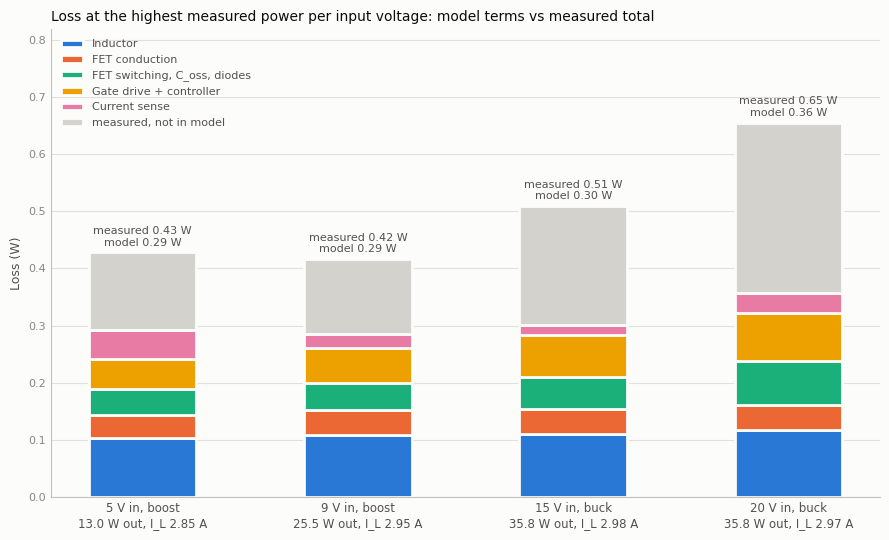

In [5]:
top = cmp.loc[cmp.groupby('Vin_nom')['P_out_W'].idxmax()].reset_index(drop=True)
low = cmp.loc[(cmp['P_out_W'] - 1.8).abs().groupby(cmp['Vin_nom']).idxmin()].reset_index(drop=True)
show = ['Vin_nom', 'mode', 'P_out_W', 'I_L', 'eta_meas', 'eta_model', 'loss_meas_W', 'loss_model_W', 'gap_W'] + list(GROUPS)
print('Highest-power bin per run (loss in W):')
print(top[show].round(3).to_string(index=False))
print('\nBin nearest 1.8 W output per run:')
print(low[show].round(3).to_string(index=False))

SEG = dict(zip(GROUPS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=SURFACE)
style(ax)
ax.grid(False, axis='x')
x = np.arange(len(top))
bottom = np.zeros(len(top))
for grp in GROUPS:
    ax.bar(x, top[grp], 0.5, bottom=bottom, color=SEG[grp], edgecolor=SURFACE, linewidth=2, label=grp)
    bottom += top[grp].to_numpy()
ax.bar(x, top['gap_W'], 0.5, bottom=bottom, color='#d3d2cc', edgecolor=SURFACE, linewidth=2,
       label='measured, not in model')
for i, r in top.iterrows():
    ax.annotate(f"measured {r['loss_meas_W']:.2f} W\nmodel {r['loss_model_W']:.2f} W",
                (x[i], r['loss_meas_W']), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8, color=INK_2)
ax.set_xticks(x, [f"{r.Vin_nom} V in, {r.mode}\n{r.P_out_W:.1f} W out, I_L {r.I_L:.2f} A" for r in top.itertuples()],
              fontsize=8.5, color=INK_2)
ax.set_ylabel('Loss (W)', fontsize=9, color=INK_2)
ax.set_ylim(0, top['loss_meas_W'].max() * 1.25)
ax.set_title('Loss at the highest measured power per input voltage: model terms vs measured total',
             loc='left', fontsize=10, color=INK)
ax.legend(frameon=False, fontsize=8, labelcolor=INK_2, loc='upper left')
fig.tight_layout()
fig.savefig('../figures/11_loss_breakdown_vs_measured.png', dpi=150, facecolor=SURFACE)
plt.show()

### Shape of the unexplained loss

A rough check of what kind of loss is missing: within each run, fit the gap (bins with P_out ≥ 3 W) as a
straight line against three candidate forms, and compare the goodness of fit (R²).

- **Inductor-path resistance:** gap ∝ I_L,rms².
- **Resistance carrying the pulsed current:** gap ∝ I_cap,rms². In boost the output capacitors carry
  I_out·√(D/(1−D)); in buck the input capacitors carry I_out·√(D(1−D)).
- **Switching-like loss:** gap ∝ V_sw·I_L.

Within one run the three currents are nearly proportional, so the R² values only separate
current-squared forms from the V·I form. The fitted coefficients are what differ between runs.

In [6]:
# Straight-line fits of the unexplained loss within each run (bins with P_out >= 3 W): gap = a + b * x
cmp['I_L_rms2'] = cmp['I_L'] ** 2 + cmp['ripple'] ** 2 / 12
i_out = cmp['P_out_W'] / cmp['Vout_V']
cmp['I_cap_rms2'] = i_out ** 2 * np.where(cmp['mode'] == 'buck', cmp['D'] * (1 - cmp['D']), cmp['D'] / (1 - cmp['D']))
cmp['V_sw_x_I_L'] = np.where(cmp['mode'] == 'buck', cmp['Vin_V'], cmp['Vout_V']) * cmp['I_L']
FORMS = {'I_L_rms2': 'inductor-path R (mOhm)', 'I_cap_rms2': 'pulsed-capacitor R (mOhm)', 'V_sw_x_I_L': 'V_sw x I_L (mW per V A)'}

shape = []
for vin, g in cmp[cmp['P_out_W'] >= 3].groupby('Vin_nom'):
    row = {'Vin_nom': vin, 'mode': g['mode'].iloc[0], 'bins': len(g)}
    for col, label in FORMS.items():
        b, a = np.polyfit(g[col], g['gap_W'], 1)
        resid = g['gap_W'] - (a + b * g[col])
        row[label] = b * 1e3
        row[f'R2 {col}'] = 1 - (resid ** 2).sum() / ((g['gap_W'] - g['gap_W'].mean()) ** 2).sum()
    shape.append(row)
print(pd.DataFrame(shape).round(3).to_string(index=False))

 Vin_nom  mode  bins  inductor-path R (mOhm)  R2 I_L_rms2  pulsed-capacitor R (mOhm)  R2 I_cap_rms2  V_sw x I_L (mW per V A)  R2 V_sw_x_I_L
       5 boost     7                  10.957        0.971                     48.297          0.970                    3.168          0.914
       9 boost    12                  12.489        0.991                     63.964          0.991                    3.402          0.962
      15  buck    16                  23.319        0.990                    157.294          0.991                    5.113          0.964
      20  buck    16                  29.951        0.990                    125.115          0.991                    4.831          0.967


## Candidates for the unexplained loss

Three terms that are outside the model can be put in numbers here: the fan commutation ripple through
the output capacitors' ESR, the PCB copper and connector path, and whatever is left after those.

- **Commutation ripple:** the fans' ~166 Hz ripple current is supplied by the output capacitors (the loop
  is far too slow to follow it, notebook 07), so it flows through their ESR. **Only one fan was ever
  measured** (notebook 02's capture: 203 mA rms of AC on 282 mA DC, one Arctic P14 Pro in open air;
  notebook 02 scales it by 8 for the startup profile). The rail ripple of the running array has not been
  measured, so it is bracketed here: N fans commutating at independent phases (rms adds as √N) and the
  worst case of all N in phase (rms adds as N). The fan count itself is uncertain — the per-header
  currents fit 3 + 4 + 1 if the fans are alike, against the 4 + 5 + 1 reported.
- **Copper and connectors:** square counts from the designer (2026-09-17, top layer, 1 oz): 3 squares from
  the input shunt to the first FET, and 2 + 3 + 0.5 squares from the last FET through the 0 Ω link and the
  two parallel 2.54 mm jumpers to the fan-rail shunt. The 12 V path is also measured directly, as the
  droop of the fan-rail voltage against fan-rail current in each run (the LM5176 regulates upstream of it).
- **Output-rail zener leakage:** the SMB5352A on the 12 V rail is specified at 1 µA at 11.5 V, below
  the 12.05 V rail, so its leakage there has to be bounded rather than read off. Its own conduction
  knee (1 mA at V_z min) sets the other end of the bound.
- **What is left** is expressed as the switching transition time that would produce it as V–I overlap,
  to compare against the model's own transition time.

In [7]:
# --- 1. Commutation ripple through the output-capacitor ESR ---
caps = pd.read_csv('../data/capacitors.csv').set_index('Part_Number')
bulk = caps.loc['LKMJ2001E472MF']                     # 4 x 4700 uF bulk bank
F_COMM = 166.0                                        # fan commutation, notebook 02 (4-pole, ~2500 rpm)
esr_bank = bulk['DF_120Hz'] / (2 * np.pi * F_COMM * bulk['Cap_uF'] * 1e-6) / 4
I_AC_1FAN, I_DC_1FAN = 0.203, 0.282                   # ONE measured fan: AC rms and mean, notebook 02 capture
P_TOP = cmp.loc[cmp['Vin_nom'] == 15, 'P_out_W'].max()
print(f"bulk bank ESR at {F_COMM:.0f} Hz (from DF): {esr_bank*1e3:.1f} mOhm")
for n_fans in (8, 10):                                # count uncertain: per-header currents fit 3 + 4 + 1
    i_fan_ac = I_AC_1FAN * ((P_TOP / 12.05 / n_fans) / I_DC_1FAN)
    for label, i_rail in [('independent phases', i_fan_ac * np.sqrt(n_fans)), ('all in phase', i_fan_ac * n_fans)]:
        print(f"  {n_fans} fans, {label:19s}: {i_rail:5.2f} A rms -> {i_rail**2 * esr_bank * 1e3:5.1f} mW")
i_ac_rail = I_AC_1FAN * ((P_TOP / 12.05 / 10) / I_DC_1FAN) * np.sqrt(10)   # used below: 10 fans, independent
print("the 47 uF input bank and the MLCCs are below 2 mW at these currents\n")

# --- 2. PCB copper and connector path (square counts from the designer, 2026-09-17; top layer, 1 oz) ---
SHEET_R = 1.72e-8 / 34.8e-6                           # 1 oz copper at 20 C
R_IN_COPPER = 3 * SHEET_R                             # input shunt -> first FET
R_OUT_COPPER = (2 + 3 + 0.5) * SHEET_R                # last FET -> 0 ohm link -> jumpers -> fan-rail shunt
print(f"1 oz copper {SHEET_R*1e3:.2f} mOhm/square: input path {R_IN_COPPER*1e3:.2f} mOhm, "
      f"output path {R_OUT_COPPER*1e3:.2f} mOhm (copper only)")
for vin_nom, fname in RUNS.items():                   # measured droop covers copper + 0 ohm link + jumpers
    df, active, _ = load(MEAS + fname, cal)
    i12 = active['fan12_A'] + active['b5in_A']
    r_meas = -np.polyfit(i12, active['fan12_V'], 1)[0]
    print(f"  measured 12 V path droop, {vin_nom} V run: {r_meas*1e3:5.1f} mOhm"
          + ("   (current range too small to fit)" if i12.max() - i12.min() < 1.5 else ""))
R_OUT_PATH = 5e-3                                     # from the 9/15/20 V droop fits

# --- 3. What the gap leaves after those terms ---
acc = top[['Vin_nom', 'mode', 'P_out_W', 'I_L', 'gap_W']].copy()
acc['I_out_A'] = top['P_out_W'] / top['Vout_V']
acc['I_in_A'] = (top['P_out_W'] + top['loss_meas_W']) / top['Vin_V']
acc['out_path_mW'] = R_OUT_PATH * acc['I_out_A'] ** 2 * 1e3
acc['in_copper_mW'] = R_IN_COPPER * acc['I_in_A'] ** 2 * 1e3
acc['cap_ESR_mW'] = i_ac_rail ** 2 * esr_bank * 1e3
acc['left_mW'] = acc['gap_W'] * 1e3 - acc[['out_path_mW', 'in_copper_mW', 'cap_ESR_mW']].sum(axis=1)
v_sw = np.where(top['mode'] == 'buck', top['Vin_V'], top['Vout_V'])
acc['t_sw_for_left_ns'] = 2 * acc['left_mW'] * 1e-3 / (v_sw * acc['I_L'] * F_SW) * 1e9
print()
print(acc.round(2).to_string(index=False))
# --- 4. Output-rail zener/TVS leakage (SMB5352A, datasheets/SMB5352A tvs jlpcb.pdf) ---
V_Z_MIN, V_R, I_R, I_ZK, Z_ZT, I_ZM = 14.25, 11.5, 1e-6, 1e-3, 2.5, 0.315
v_rail = top['Vout_V'].mean()
dec_per_v = (np.log10(I_ZK) - np.log10(I_R)) / (V_Z_MIN - V_R)      # only two points are specified
i_leak = 10 ** (np.log10(I_R) + dec_per_v * (v_rail - V_R))
print(f"\nzener leakage at the {v_rail:.2f} V rail: specified only as {I_R*1e6:.0f} uA at {V_R} V and the "
      f"{I_ZK*1e3:.0f} mA knee at {V_Z_MIN} V")
for i_lk, label in [(i_leak, f'log-linear estimate, {i_leak*1e6:.1f} uA'), (100e-6, '100 uA, 100x the spec'),
                    (I_ZK, 'at the knee current, 1 mA')]:
    p = i_lk * v_rail
    print(f"  {label:32s}: {p*1e3:6.2f} mW = {100*p/36:.4f} % of 36 W, {100*p/1.5:.3f} % of the 1.5 W point")
print(f"  clamp at I_zm {I_ZM*1e3:.0f} mA: {15.75 + I_ZM*Z_ZT:.1f} V, against 30 V FETs and 25 V output caps; "
      f"V_z min is {100*(V_Z_MIN/v_rail-1):.0f} % above the rail")

print(f"\nt_sw_for_left_ns: total transition time that would give the remaining loss as V-I overlap; "
      f"the model uses {(Q_GD*(IC.R_LDRV_PULLUP+R_G)/(V_DRV-V_PL) + Q_GD*(IC.R_LDRV_PULLDOWN+R_G)/V_PL)*1e9:.1f} ns")

bulk bank ESR at 166 Hz (from DF): 7.1 mOhm
  8 fans, independent phases :  0.76 A rms ->   4.1 mW
  8 fans, all in phase       :  2.14 A rms ->  32.7 mW
  10 fans, independent phases :  0.68 A rms ->   3.3 mW
  10 fans, all in phase       :  2.14 A rms ->  32.7 mW
the 47 uF input bank and the MLCCs are below 2 mW at these currents

1 oz copper 0.49 mOhm/square: input path 1.48 mOhm, output path 2.72 mOhm (copper only)
  measured 12 V path droop, 5 V run:  -1.7 mOhm   (current range too small to fit)
  measured 12 V path droop, 9 V run:   4.0 mOhm
  measured 12 V path droop, 15 V run:   3.9 mOhm
  measured 12 V path droop, 20 V run:   6.3 mOhm

 Vin_nom  mode  P_out_W  I_L  gap_W  I_out_A  I_in_A  out_path_mW  in_copper_mW  cap_ESR_mW  left_mW  t_sw_for_left_ns
       5 boost    13.00 2.85   0.14     1.08    2.88         5.79         12.31        3.27   113.86             66.08
       9 boost    25.55 2.95   0.13     2.12    2.97        22.40         13.07        3.27    91.84         

# Final Conclusions

**The calculated efficiency is optimistic, by an amount that depends on the operating mode.** Notebook
03/04 loss terms at each measured point with the V1 parts, against the measured loss:

| Operating point (highest-power bin) | Efficiency, measured / calculated | Loss, measured / calculated | Not in model |
|---|---|---|---|
| 5 V boost, 13.0 W out, I_L 2.85 A | 96.8 % / 97.8 % | 0.43 / 0.29 W | 0.14 W |
| 9 V boost, 25.5 W out, I_L 2.95 A | 98.4 % / 98.9 % | 0.42 / 0.29 W | 0.13 W |
| 15 V buck, 35.8 W out, I_L 2.98 A | 98.6 % / 99.2 % | 0.51 / 0.30 W | 0.21 W |
| 20 V buck, 35.8 W out, I_L 2.97 A | 98.2 % / 99.0 % | 0.65 / 0.36 W | 0.30 W |

- **Above ~5 W** the model is 0.25–1.0 points of efficiency high.
- **At ~1.8 W** it is 0.5–2.9 points high. There the measurement is only good to about ±1.3 points,
  and the forced-CCM assumption is unverified.
- **Shape:** within each run the unexplained loss grows with the square of current (R² 0.97–0.99, against
  0.91–0.97 for a V·I switching form).
  - As an inductor-path resistance it is 11–12 mΩ in boost but 23–30 mΩ in buck, so no single missing
    resistance explains all four runs.
  - **Capacitor ESR is ruled out** as the explanation: the commutation ripple through the bulk bank's
    ESR is ~3 mW with independent fan phases, and 21–33 mW even in the worst case of all fans in phase.
    The switching-frequency ripple through the input bank is below 2 mW.
  - **PCB copper and connectors are a small part:** the measured 12 V path (copper + 0 Ω link + the two
    parallel jumpers) is 4–6 mΩ, worth 42 mW at 2.9 A out, and the input copper ~1.5 mΩ, 5–12 mW.
  - **What remains is 0.10–0.25 W**, largest at 20 V. As V–I overlap it would need 59–86 ns of total
    transition time against the model's 5.5 ns, so the model's switching term (transition time from Q_gd
    and the driver resistance alone) is the most likely underestimate, with inductor core loss and
    R_DS(on) temperature rise next.
- **Inductor AC term:** the Rp estimate is 3 mW against REDEXPERT's 12 mW at 5 V / 3 A. That 9 mW is
  small next to the gap.
- **Output-rail zener leakage is negligible:** ~4 µA (0.05 mW) at the 12.05 V rail by log-linear
  interpolation between the two specified points, and 1.2 mW even at 100 times the 11.5 V spec — below
  the ±2 mA fan-rail offset (24 mW) that limits the measurement, so it could not be seen anyway. The
  part is also 18 % above the rail at its minimum V_z and clamps at 16.5 V at I_zm, inside the 30 V FET
  and 25 V capacitor ratings. No change needed.

**Decision:** no change to the V1 parts. For V2, measure the switching transitions and add a realistic
switching term before choosing parts on 14–84 mW differences.

**What would locate the unexplained loss:**
1. SW1 and SW2 waveforms at 20 V and 5 V: real transition times and ringing (also needed for notebook 04's
   30 V margin question). This is the first measurement to take.
2. A thermal image at 20 V / 36 W and at 5 V / 3 A, to see which parts run hot.
3. The rail ripple current of the running fan array, to replace the single-fan estimate.
4. REDEXPERT runs for 7443634700 at 9, 15 and 20 V.
5. The LM5176 MODE setting on V1 (forced PWM or diode emulation), which decides the light-load model.